In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [2]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 5.0

run = 1


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(run))

# Load and setup the data

In [3]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_tritrig.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_phiKK.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_wab.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  149433
phiKK:  6232
wab:  16422


In [4]:
# Make Training set
tritrig_train = df_tritrig[0:50000]
wab_train = df_wab[0:6000]
phiKK_train = df_phiKK[0:5000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Make a training set with balanced classes (as expected in data), used for scaling
df_train_balanced = pd.concat([df_phiKK[0:25], df_tritrig[0:(1470*25)] , df_wab[0:(228*25)]], ignore_index=True, sort=False).drop(columns=['PhiKK'])

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( df_train_balanced ), n_bins=Num_classes)
np.save("one_hot_edges.npy", one_hot_edges)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[50000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[6000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[5000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_62363/1684390729.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_62363/1684390729.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_62363/1684390729.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [5]:
# Make a training set with balanced classes (as expected in data), used for scaling
df_train_balanced = pd.concat([df_phiKK[0:25], df_tritrig[0:(1470*25)] , df_wab[0:(228*25)]], ignore_index=True, sort=False).drop(columns=['PhiKK'])

# Replace -9999 sentinel values (missing electron Ecal cluster) with NaN
# so they don't corrupt the scaler statistics
SENTINEL_COLS = ['ele_Ecal_x', 'ele_Ecal_y', 'ele_Ecal_z']
                                        
for df in [X_train, X_val, X_test, df_train_balanced]:
    df[SENTINEL_COLS] = df[SENTINEL_COLS].replace(-9999.0, np.nan)

# Impute NaN with training-set column means, then standardize
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
])


df_train_balanced = pd.DataFrame(pipeline.fit_transform(df_train_balanced), columns=df_train_balanced.columns, index=df_train_balanced.index)
X_train = pd.DataFrame(pipeline.transform(X_train),     columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(pipeline.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test  = pd.DataFrame(pipeline.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Save the pipeline so it can be applied consistently during inference
joblib.dump(pipeline, "/Users/mghrear/data/ML_data/2019_pass2/scaler_2019_pass2.pkl")

print(f"Standardized {X_train.shape[1]} features using training-set statistics.")

Standardized 19 features using training-set statistics.


## Setup dataloaders

In [6]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [7]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-3)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [8]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.369054
Validation loss: 0.372538 

Epoch 2
-------------------------------
Training loss: 0.194219
Validation loss: 0.159680 

Epoch 3
-------------------------------
Training loss: 0.131467
Validation loss: 0.108408 

Epoch 4
-------------------------------
Training loss: 0.094416
Validation loss: 0.084150 

Epoch 5
-------------------------------
Training loss: 0.070545
Validation loss: 0.066313 

Epoch 6
-------------------------------
Training loss: 0.054735
Validation loss: 0.055343 

Epoch 7
-------------------------------
Training loss: 0.043526
Validation loss: 0.045615 

Epoch 8
-------------------------------
Training loss: 0.036777
Validation loss: 0.038954 

Epoch 9
-------------------------------
Training loss: 0.030275
Validation loss: 0.035525 

Epoch 10
-------------------------------
Training loss: 0.026138
Validation loss: 0.032503 

Epoch 11
-------------------------------
Training loss: 0.022594
Validation los

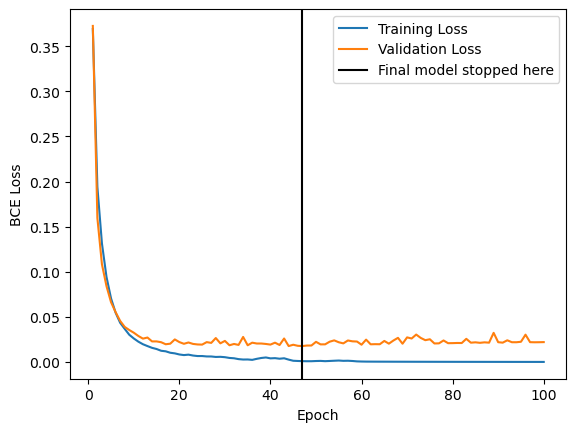

In [9]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9952


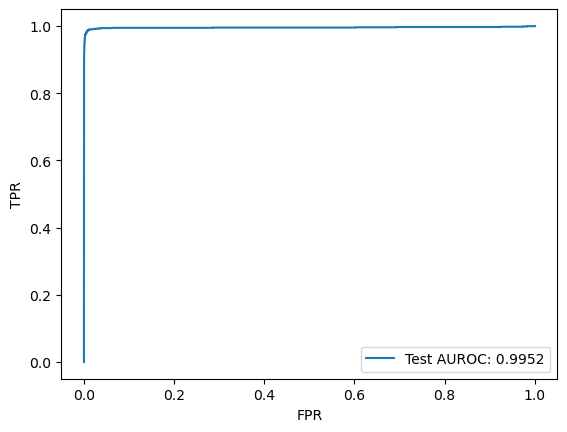

In [10]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

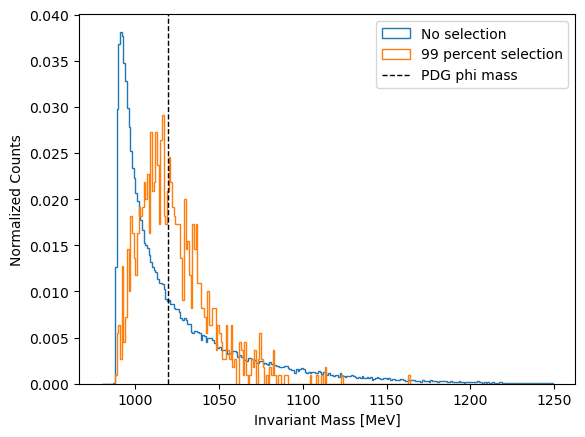

In [11]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [12]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/pretrained_classifier_2019_pass2_run"+str(run)+"_scaled.pt")

# Setup the adversary model

## Initialize model, objective function, and optimizer

In [13]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-3)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [14]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [15]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.421331
Validation loss: 2.317366 

Epoch 2
-------------------------------
Training loss: 2.314095
Validation loss: 2.309476 

Epoch 3
-------------------------------
Training loss: 2.305099
Validation loss: 2.307518 

Epoch 4
-------------------------------
Training loss: 2.304942
Validation loss: 2.304587 

Epoch 5
-------------------------------
Training loss: 2.304620
Validation loss: 2.309271 

Epoch 6
-------------------------------
Training loss: 2.305353
Validation loss: 2.305321 

Epoch 7
-------------------------------
Training loss: 2.304357
Validation loss: 2.304107 

Epoch 8
-------------------------------
Training loss: 2.304421
Validation loss: 2.303559 

Epoch 9
-------------------------------
Training loss: 2.305492
Validation loss: 2.305039 

Epoch 10
-------------------------------
Training loss: 2.304909
Validation loss: 2.304675 

Epoch 11
-------------------------------
Training loss: 2.304142
Validation los

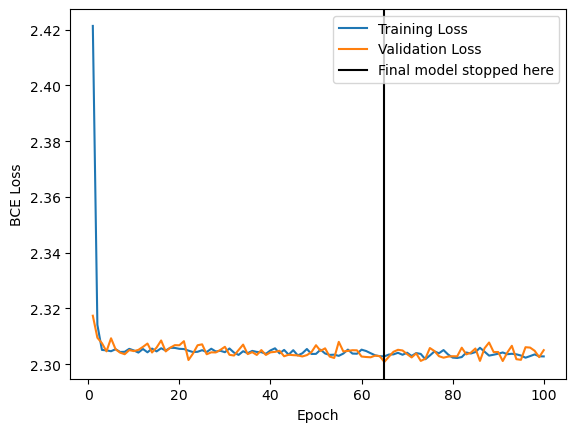

In [16]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [17]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [18]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [19]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-4,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-3,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -11.503978
Adversary training loss: 2.301932
Classifier validation loss: -11.419367
Adversary validation loss: 2.287862
Diff score: 1.744786


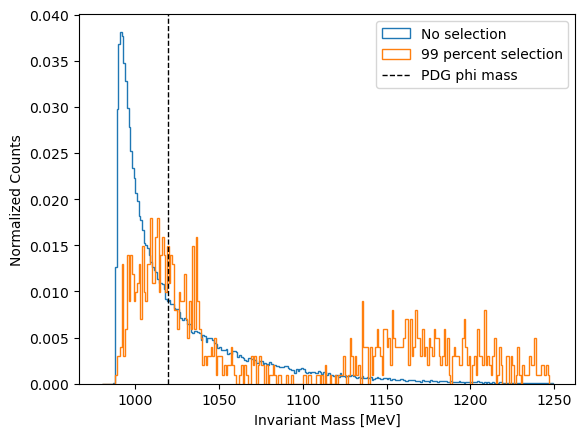

Epoch 2
-------------------------------
Classifier training loss: -11.443321
Adversary training loss: 2.291718
Classifier validation loss: -11.197455
Adversary validation loss: 2.245759
Diff score: 1.808492


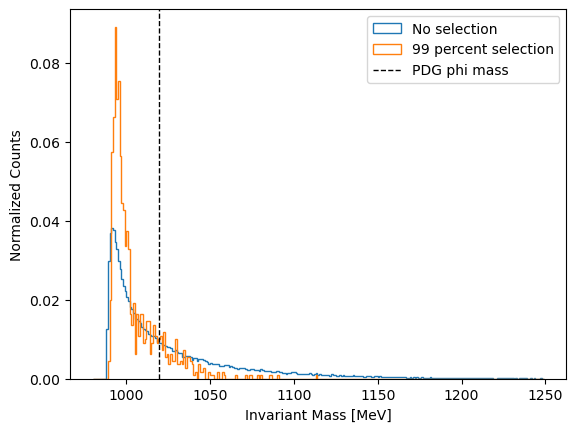

Epoch 3
-------------------------------
Classifier training loss: -11.397737
Adversary training loss: 2.294937
Classifier validation loss: -11.317780
Adversary validation loss: 2.291930
Diff score: 2.435268


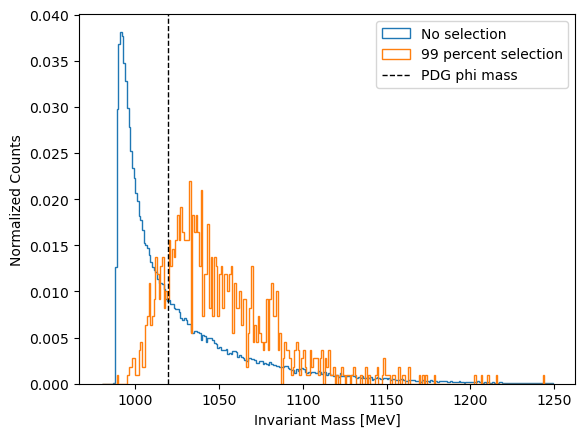

Epoch 4
-------------------------------
Classifier training loss: -11.250833
Adversary training loss: 2.265472
Classifier validation loss: -11.377556
Adversary validation loss: 2.282166
Diff score: 2.055093


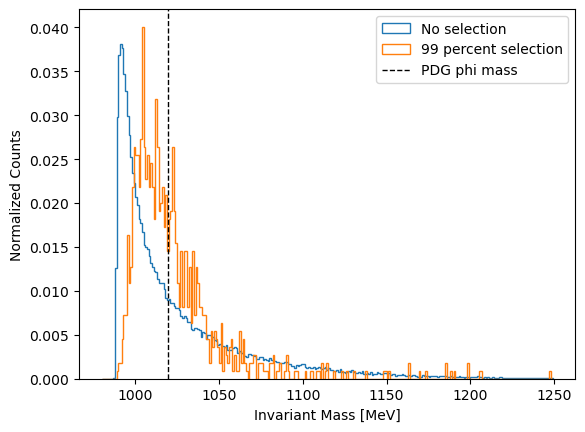

Epoch 5
-------------------------------
Classifier training loss: -11.486917
Adversary training loss: 2.300657
Classifier validation loss: -11.416981
Adversary validation loss: 2.288455
Diff score: 1.513377


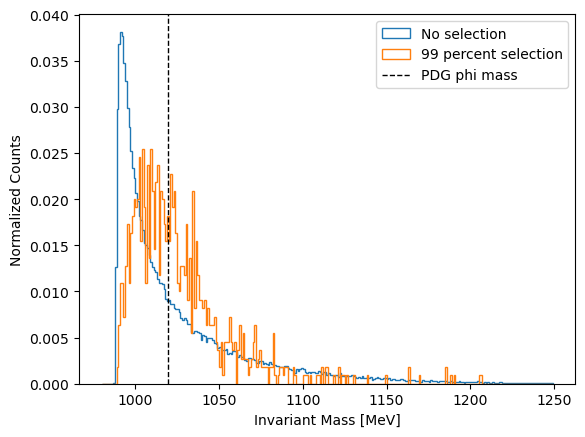

Epoch 6
-------------------------------
Classifier training loss: -11.479030
Adversary training loss: 2.299133
Classifier validation loss: -11.528170
Adversary validation loss: 2.310264
Diff score: 1.972852


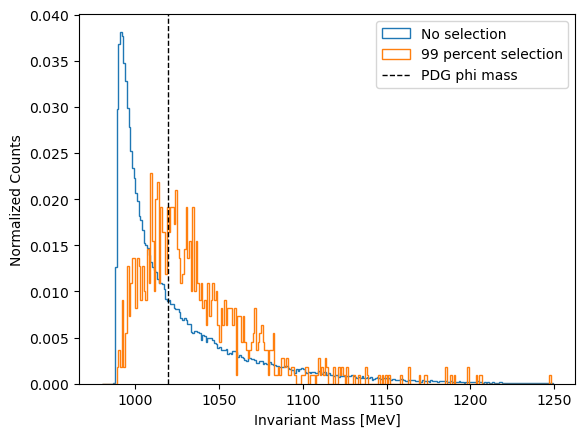

Epoch 7
-------------------------------
Classifier training loss: -11.483707
Adversary training loss: 2.297601
Classifier validation loss: -11.461695
Adversary validation loss: 2.296862
Diff score: 1.879195


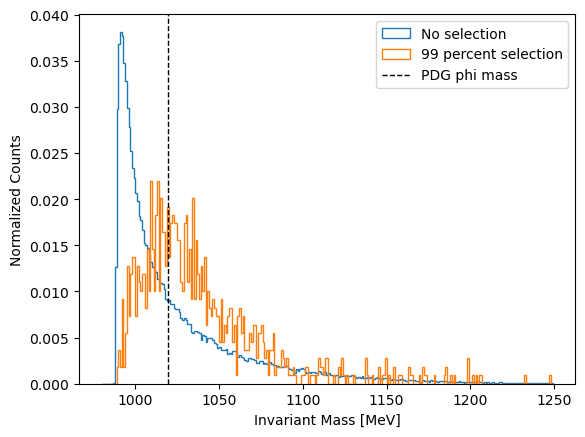

Epoch 8
-------------------------------
Classifier training loss: -11.483015
Adversary training loss: 2.298931
Classifier validation loss: -11.475083
Adversary validation loss: 2.299219
Diff score: 1.683313


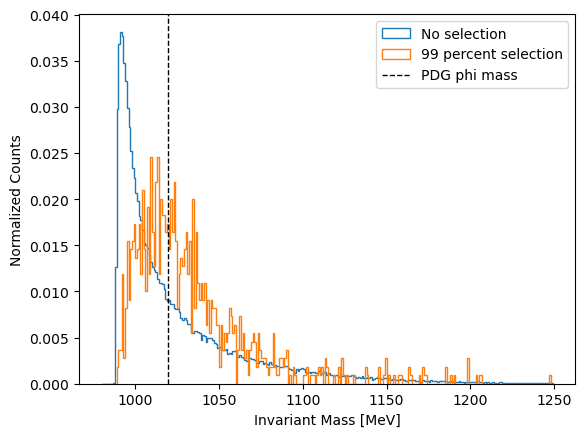

Epoch 9
-------------------------------
Classifier training loss: -11.485156
Adversary training loss: 2.298339
Classifier validation loss: -11.496749
Adversary validation loss: 2.303438
Diff score: 1.730903


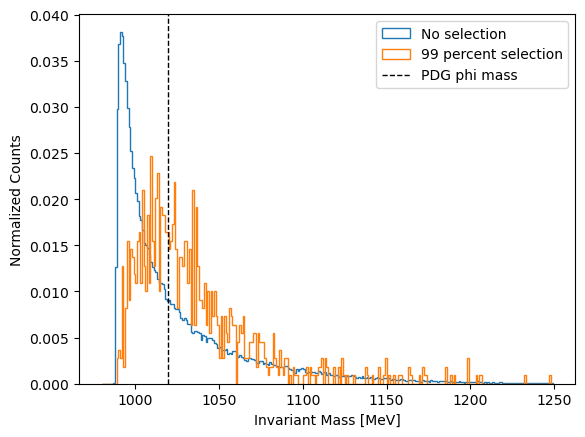

Epoch 10
-------------------------------
Classifier training loss: -11.510413
Adversary training loss: 2.302719
Classifier validation loss: -11.501445
Adversary validation loss: 2.305244
Diff score: 1.734709


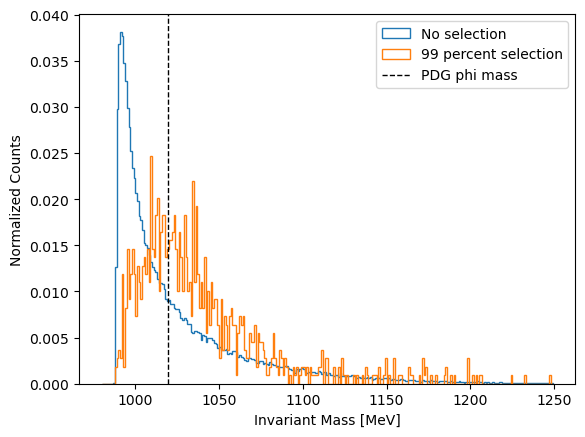

Epoch 11
-------------------------------
Classifier training loss: -11.515319
Adversary training loss: 2.303910
Classifier validation loss: -11.506284
Adversary validation loss: 2.306238
Diff score: 1.411155


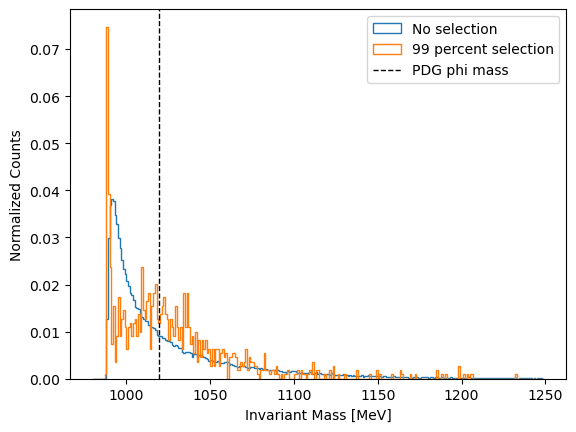

Epoch 12
-------------------------------
Classifier training loss: -11.516190
Adversary training loss: 2.303794
Classifier validation loss: -11.511182
Adversary validation loss: 2.307822
Diff score: 1.480877


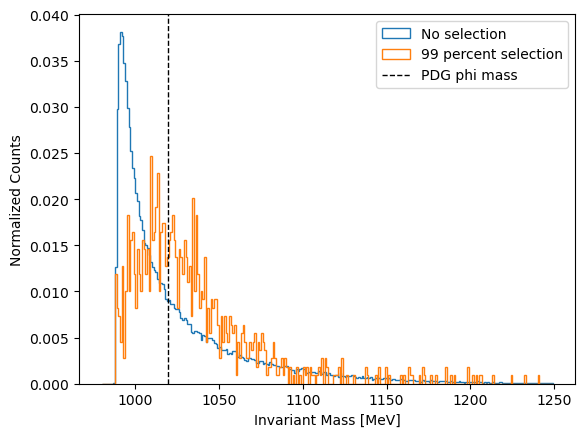

Epoch 13
-------------------------------
Classifier training loss: -11.511772
Adversary training loss: 2.303424
Classifier validation loss: -11.506532
Adversary validation loss: 2.305337
Diff score: 1.536115


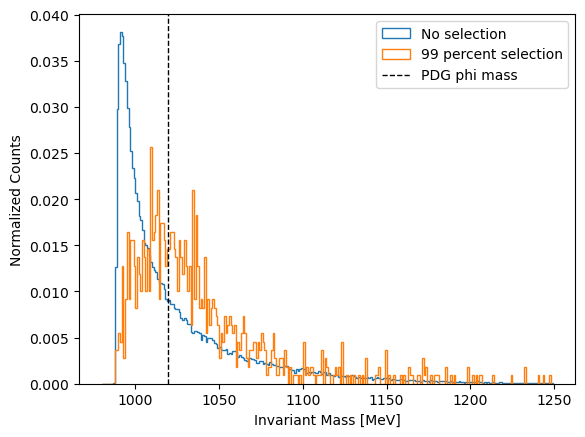

Epoch 14
-------------------------------
Classifier training loss: -11.518203
Adversary training loss: 2.304028
Classifier validation loss: -11.501004
Adversary validation loss: 2.304094
Diff score: 1.530677


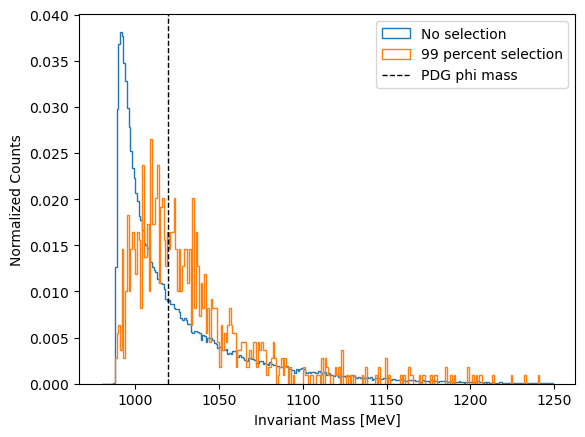

Epoch 15
-------------------------------
Classifier training loss: -11.514266
Adversary training loss: 2.304089
Classifier validation loss: -11.501409
Adversary validation loss: 2.304199
Diff score: 1.589689


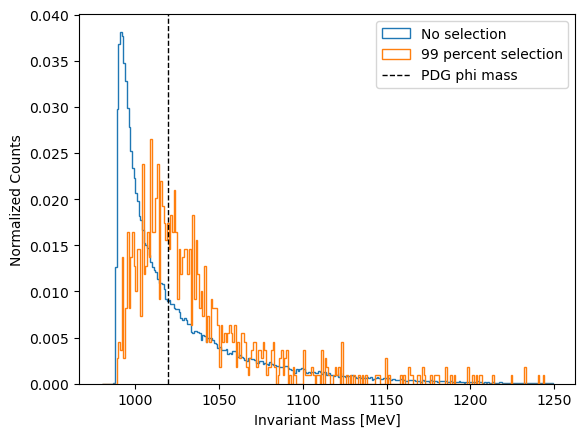

Epoch 16
-------------------------------
Classifier training loss: -11.514934
Adversary training loss: 2.303638
Classifier validation loss: -11.524831
Adversary validation loss: 2.308868
Diff score: 1.523090


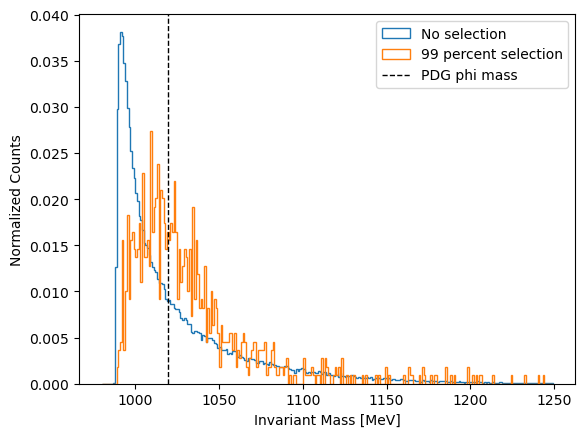

Epoch 17
-------------------------------
Classifier training loss: -11.520103
Adversary training loss: 2.304111
Classifier validation loss: -11.508146
Adversary validation loss: 2.305508
Diff score: 1.588624


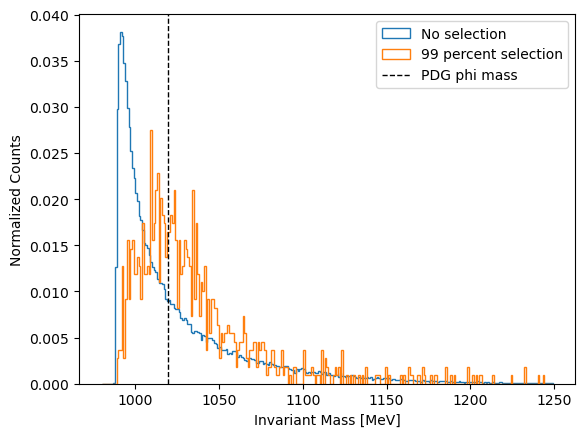

Epoch 18
-------------------------------
Classifier training loss: -11.511758
Adversary training loss: 2.303838
Classifier validation loss: -11.504500
Adversary validation loss: 2.305245
Diff score: 1.596390


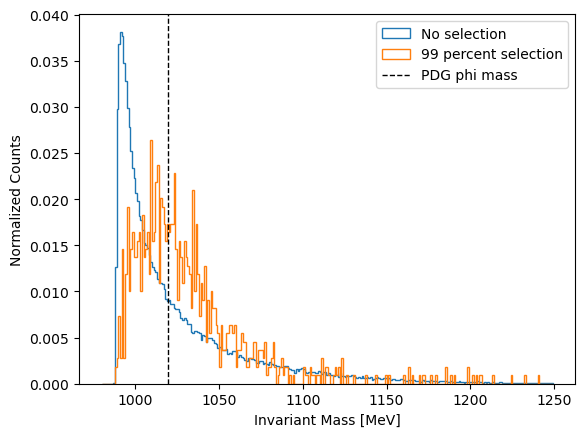

Epoch 19
-------------------------------
Classifier training loss: -11.518039
Adversary training loss: 2.304617
Classifier validation loss: -11.506742
Adversary validation loss: 2.305148
Diff score: 1.546206


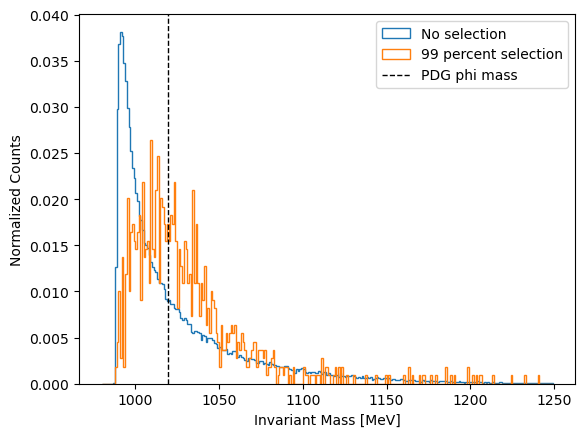

Epoch 20
-------------------------------
Classifier training loss: -11.515127
Adversary training loss: 2.303994
Classifier validation loss: -11.506691
Adversary validation loss: 2.305848
Diff score: 1.499457


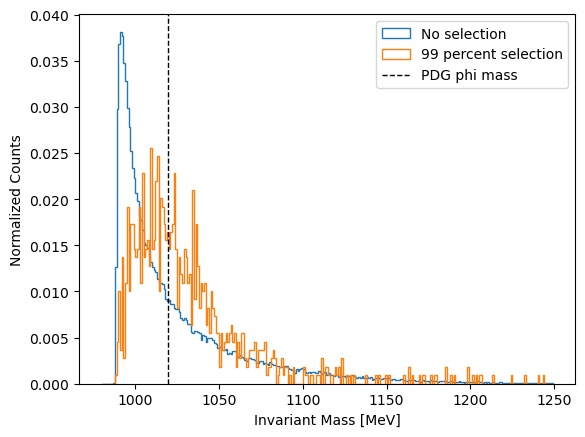

Epoch 21
-------------------------------
Classifier training loss: -11.517431
Adversary training loss: 2.304513
Classifier validation loss: -11.506319
Adversary validation loss: 2.305050
Diff score: 1.215149


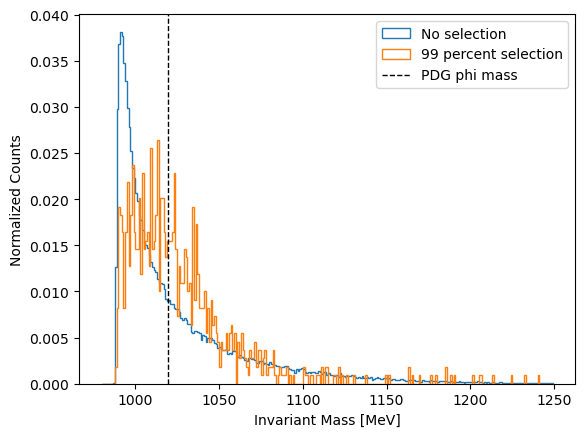

Epoch 22
-------------------------------
Classifier training loss: -11.518534
Adversary training loss: 2.304295
Classifier validation loss: -11.504744
Adversary validation loss: 2.304996
Diff score: 1.262851


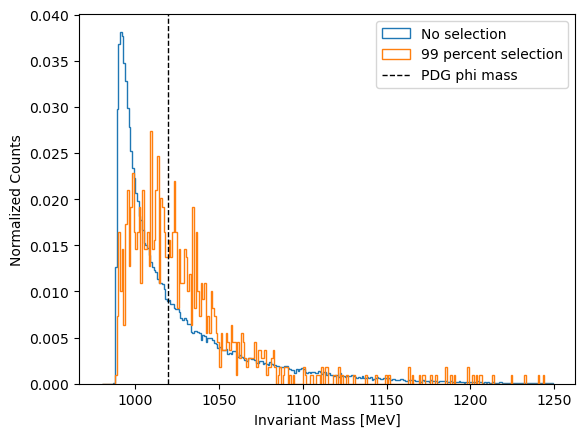

Epoch 23
-------------------------------
Classifier training loss: -11.515043
Adversary training loss: 2.304354
Classifier validation loss: -11.518503
Adversary validation loss: 2.307447
Diff score: 1.182047


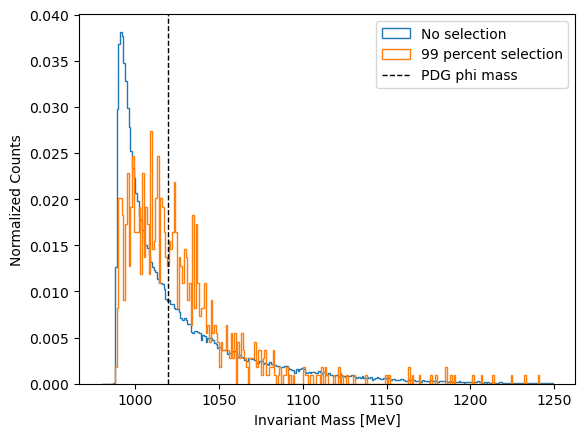

Epoch 24
-------------------------------
Classifier training loss: -11.512507
Adversary training loss: 2.303714
Classifier validation loss: -11.504055
Adversary validation loss: 2.304596
Diff score: 1.095193


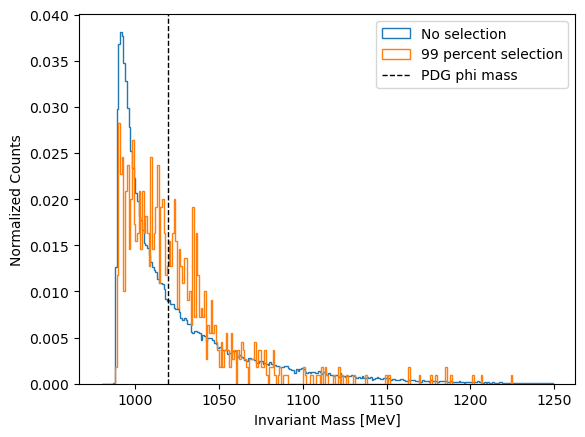

Epoch 25
-------------------------------
Classifier training loss: -11.516179
Adversary training loss: 2.303712
Classifier validation loss: -11.489171
Adversary validation loss: 2.303867
Diff score: 1.106142


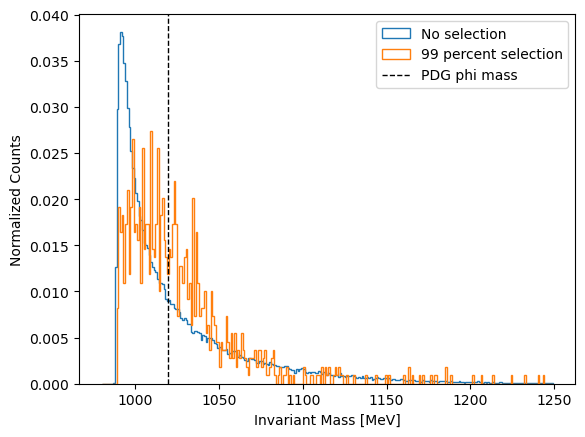

Epoch 26
-------------------------------
Classifier training loss: -11.513614
Adversary training loss: 2.303648
Classifier validation loss: -11.500427
Adversary validation loss: 2.303933
Diff score: 0.907869


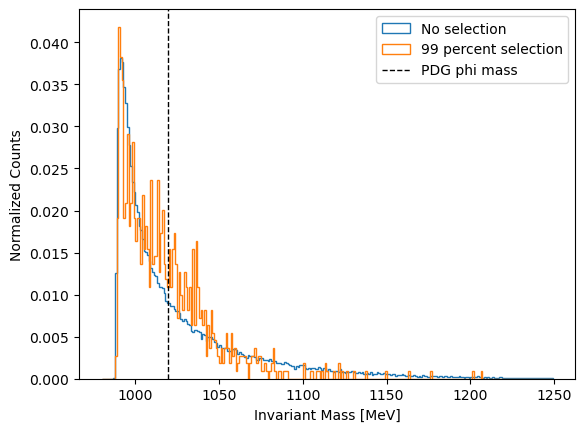

Epoch 27
-------------------------------
Classifier training loss: -11.509494
Adversary training loss: 2.303143
Classifier validation loss: -11.510516
Adversary validation loss: 2.306927
Diff score: 0.941798


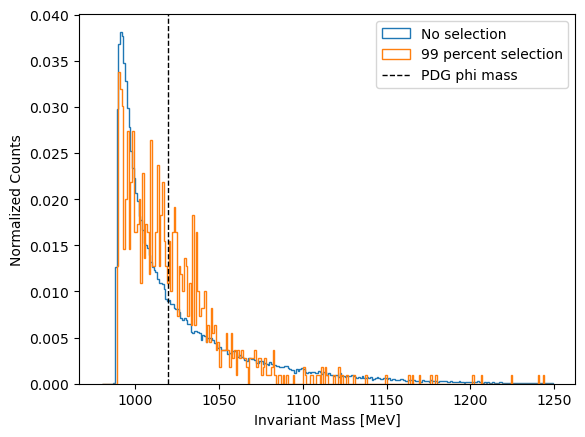

Epoch 28
-------------------------------
Classifier training loss: -11.507873
Adversary training loss: 2.302272
Classifier validation loss: -11.508435
Adversary validation loss: 2.305627
Diff score: 1.114410


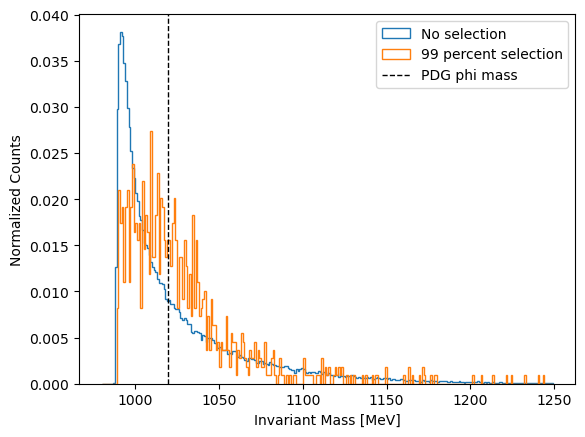

Epoch 29
-------------------------------
Classifier training loss: -11.512900
Adversary training loss: 2.303322
Classifier validation loss: -11.483692
Adversary validation loss: 2.300580
Diff score: 1.078911


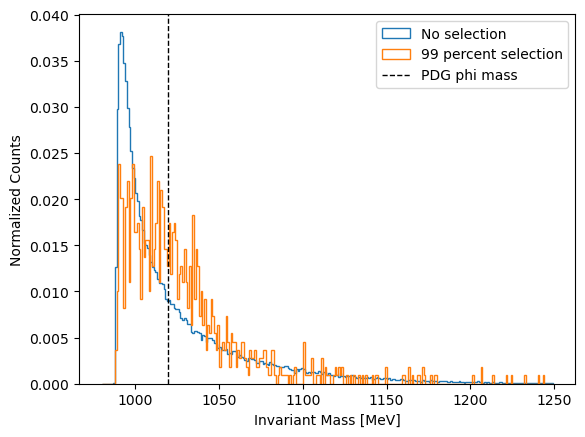

Epoch 30
-------------------------------
Classifier training loss: -11.503402
Adversary training loss: 2.302659
Classifier validation loss: -11.500339
Adversary validation loss: 2.304011
Diff score: 1.333841


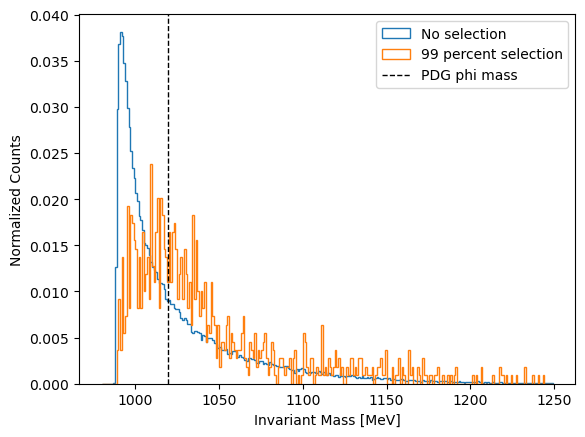

Epoch 31
-------------------------------
Classifier training loss: -11.511692
Adversary training loss: 2.303433
Classifier validation loss: -11.504988
Adversary validation loss: 2.305194
Diff score: 0.866643


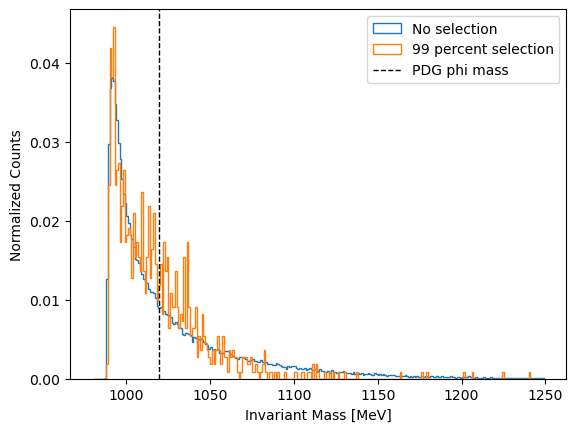

Epoch 32
-------------------------------
Classifier training loss: -11.511266
Adversary training loss: 2.303201
Classifier validation loss: -11.500528
Adversary validation loss: 2.304014
Diff score: 0.855677


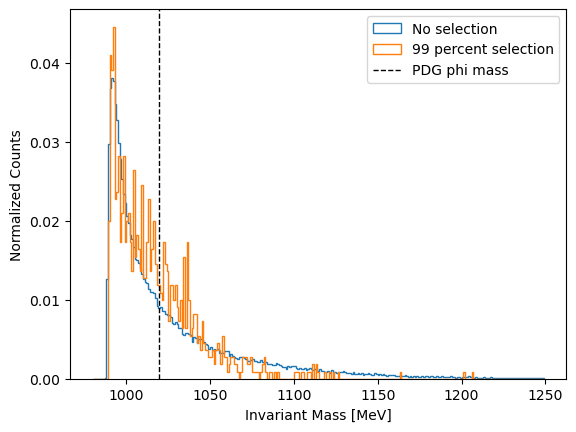

Epoch 33
-------------------------------
Classifier training loss: -11.514506
Adversary training loss: 2.303820
Classifier validation loss: -11.498955
Adversary validation loss: 2.305152
Diff score: 0.893922


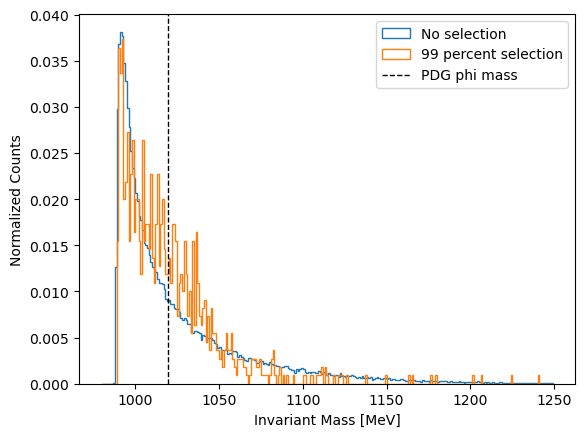

Epoch 34
-------------------------------
Classifier training loss: -11.516858
Adversary training loss: 2.304207
Classifier validation loss: -11.502924
Adversary validation loss: 2.305070
Diff score: 0.873772


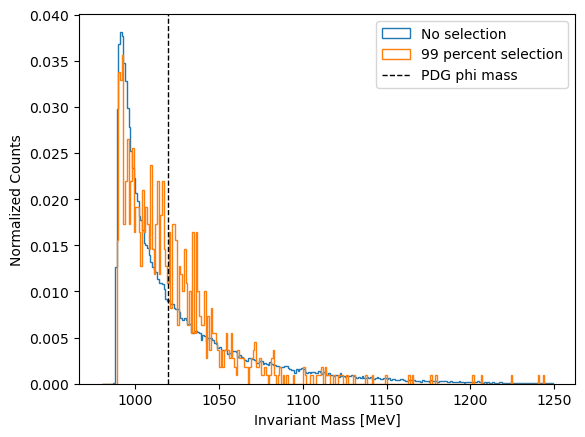

Epoch 35
-------------------------------
Classifier training loss: -11.515453
Adversary training loss: 2.304092
Classifier validation loss: -11.526764
Adversary validation loss: 2.309771
Diff score: 0.885156


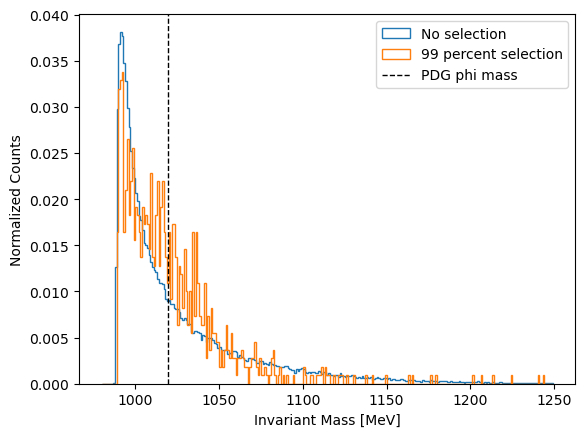

Epoch 36
-------------------------------
Classifier training loss: -11.515950
Adversary training loss: 2.304063
Classifier validation loss: -11.513020
Adversary validation loss: 2.306698
Diff score: 0.929328


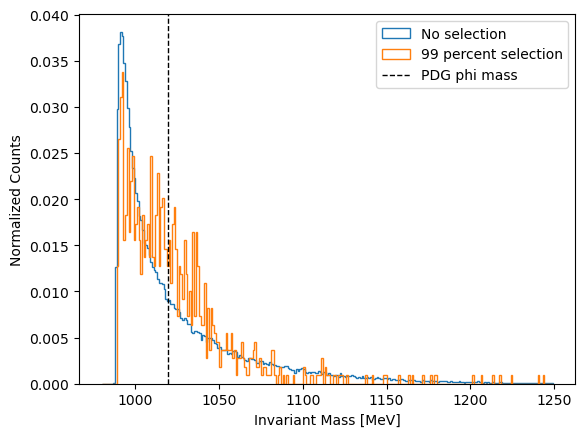

Epoch 37
-------------------------------
Classifier training loss: -11.515178
Adversary training loss: 2.303734
Classifier validation loss: -11.504599
Adversary validation loss: 2.304829
Diff score: 0.933671


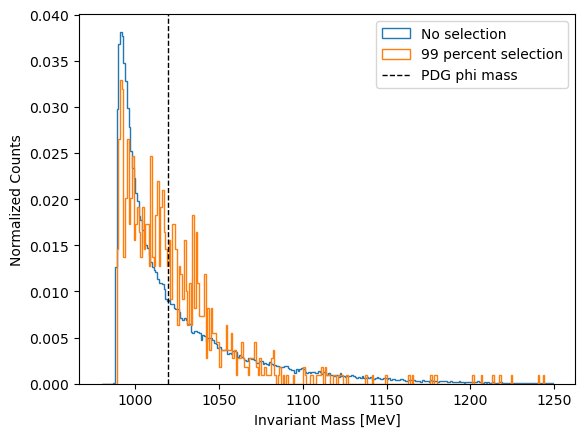

Epoch 38
-------------------------------
Classifier training loss: -11.514926
Adversary training loss: 2.303703
Classifier validation loss: -11.514704
Adversary validation loss: 2.306755
Diff score: 0.974738


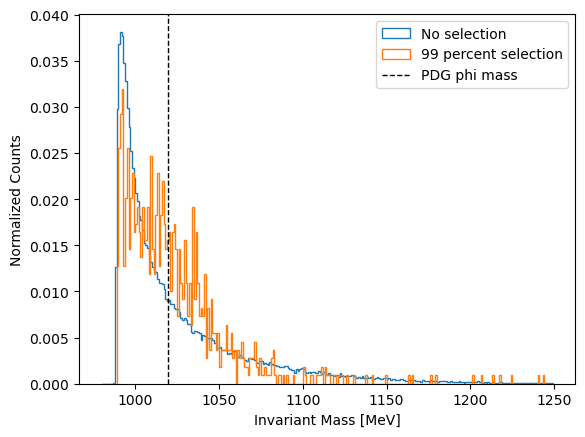

Epoch 39
-------------------------------
Classifier training loss: -11.514008
Adversary training loss: 2.304006
Classifier validation loss: -11.512732
Adversary validation loss: 2.306365
Diff score: 0.956367


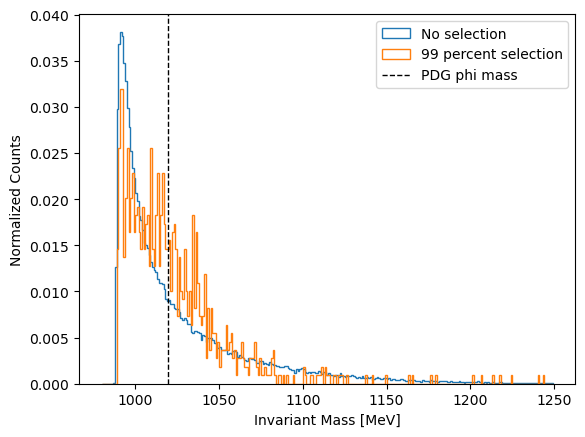

Epoch 40
-------------------------------
Classifier training loss: -11.518173
Adversary training loss: 2.303841
Classifier validation loss: -11.512313
Adversary validation loss: 2.306788
Diff score: 1.070576


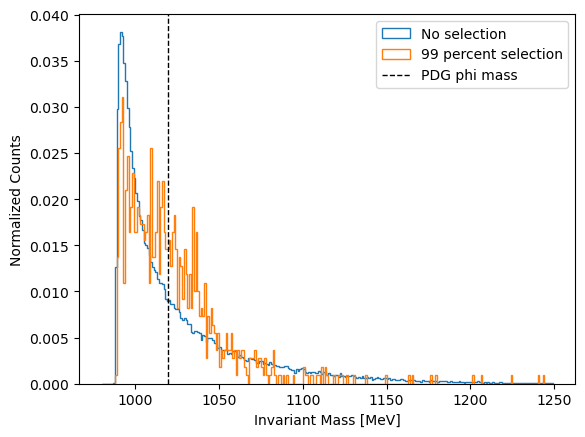

Epoch 41
-------------------------------
Classifier training loss: -11.515863
Adversary training loss: 2.304006
Classifier validation loss: -11.510787
Adversary validation loss: 2.306469
Diff score: 1.056578


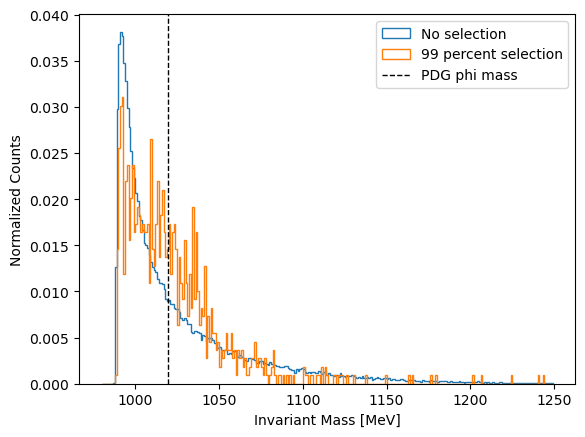

Epoch 42
-------------------------------
Classifier training loss: -11.513182
Adversary training loss: 2.303706
Classifier validation loss: -11.505526
Adversary validation loss: 2.304899
Diff score: 1.092075


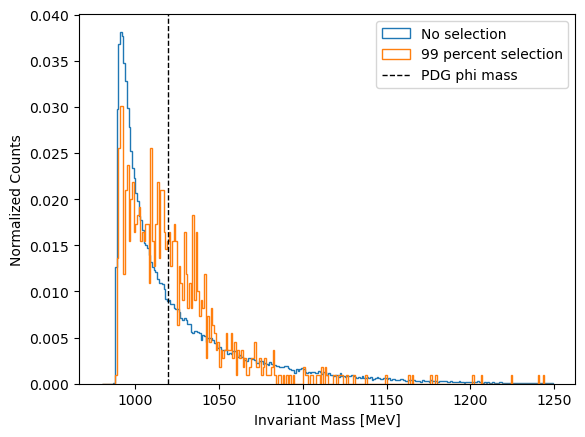

Epoch 43
-------------------------------
Classifier training loss: -11.517565
Adversary training loss: 2.303765
Classifier validation loss: -11.510942
Adversary validation loss: 2.306266
Diff score: 1.045301


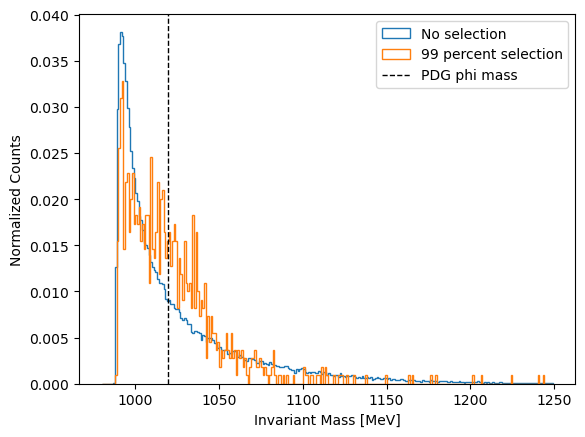

Epoch 44
-------------------------------
Classifier training loss: -11.514434
Adversary training loss: 2.303392
Classifier validation loss: -11.502103
Adversary validation loss: 2.304739
Diff score: 0.960689


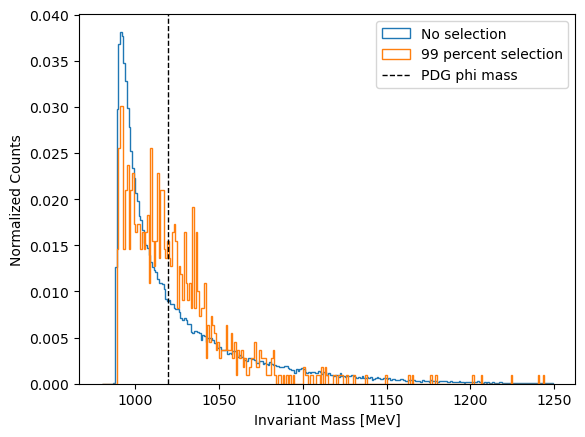

Epoch 45
-------------------------------
Classifier training loss: -11.512904
Adversary training loss: 2.303858
Classifier validation loss: -11.505226
Adversary validation loss: 2.304784
Diff score: 1.099105


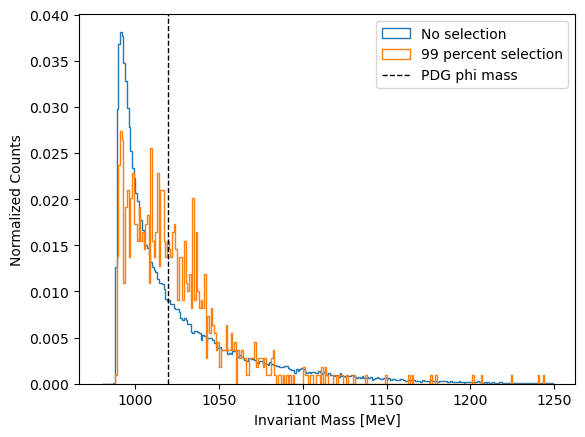

Epoch 46
-------------------------------
Classifier training loss: -11.515401
Adversary training loss: 2.303799
Classifier validation loss: -11.507650
Adversary validation loss: 2.305306
Diff score: 0.988712


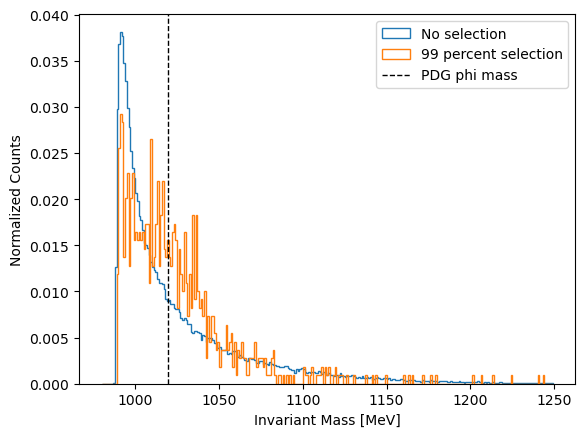

Epoch 47
-------------------------------
Classifier training loss: -11.513120
Adversary training loss: 2.303563
Classifier validation loss: -11.500919
Adversary validation loss: 2.304957
Diff score: 1.087980


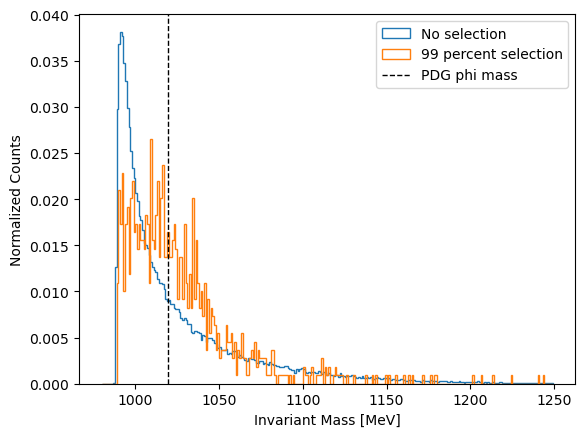

Epoch 48
-------------------------------
Classifier training loss: -11.514896
Adversary training loss: 2.303760
Classifier validation loss: -11.518656
Adversary validation loss: 2.307750
Diff score: 1.076831


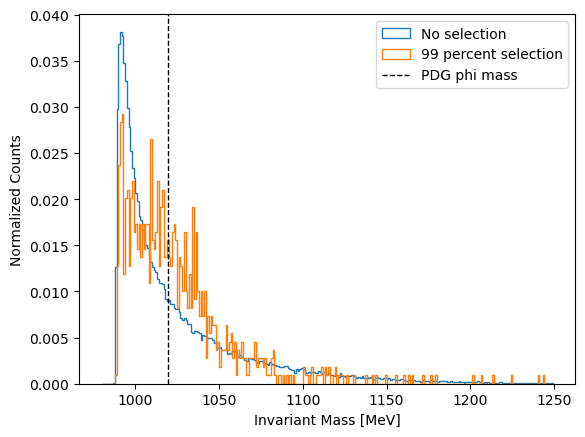

Epoch 49
-------------------------------
Classifier training loss: -11.514976
Adversary training loss: 2.303463
Classifier validation loss: -11.504277
Adversary validation loss: 2.304618
Diff score: 1.079372


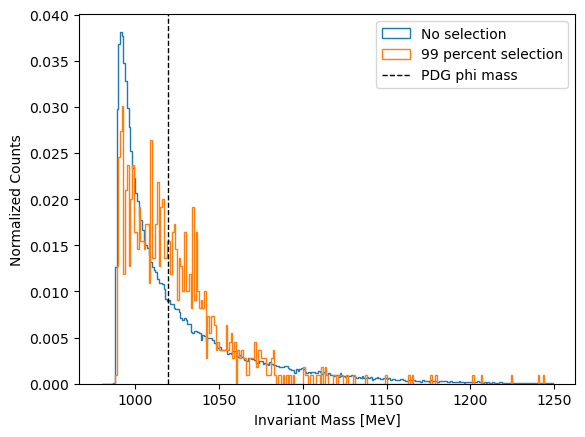

Epoch 50
-------------------------------
Classifier training loss: -11.513858
Adversary training loss: 2.303489
Classifier validation loss: -11.506258
Adversary validation loss: 2.305044
Diff score: 0.990899


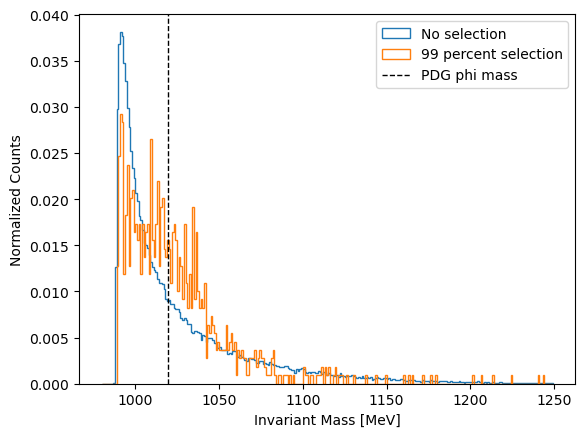

Done!


In [20]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],99)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

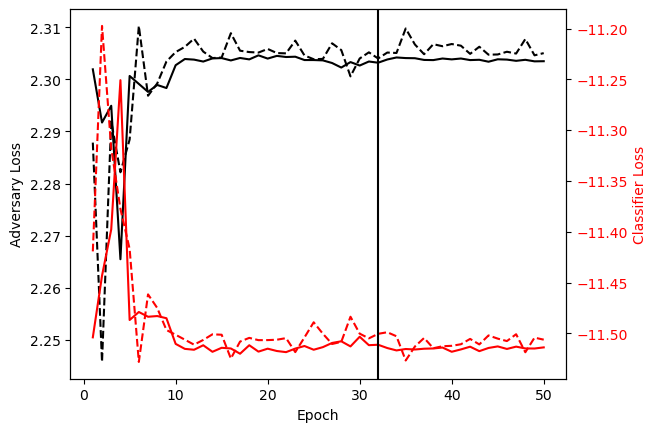

In [21]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

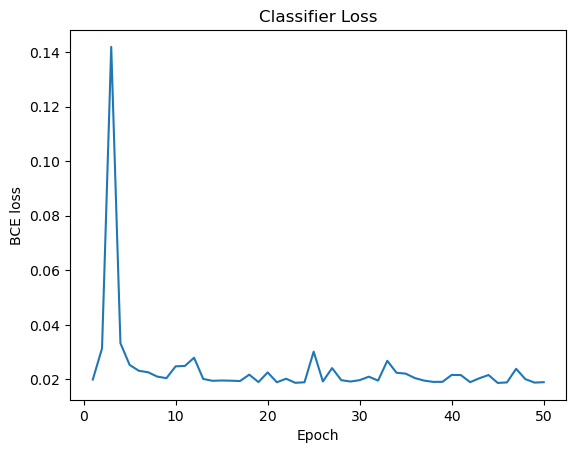

In [22]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9935


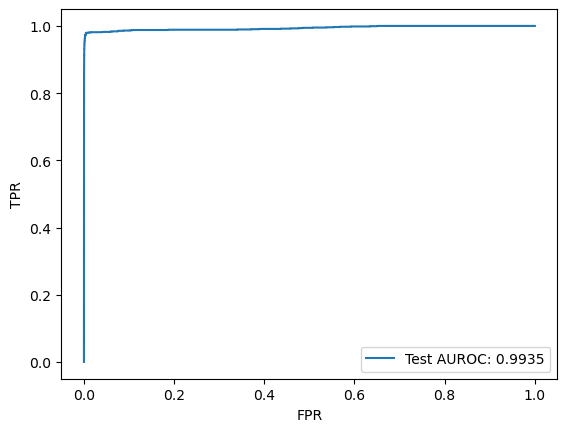

In [23]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

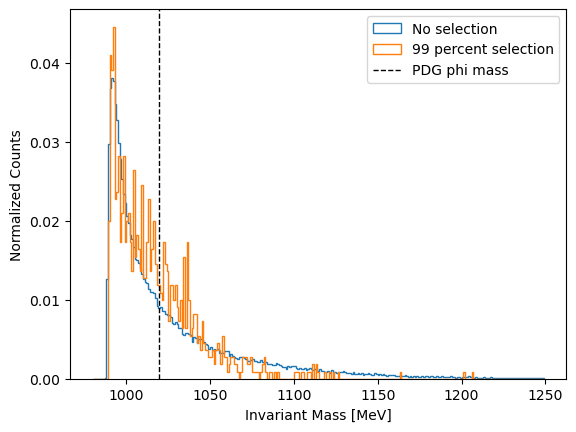

In [24]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [25]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean( np.abs( N2/np.sum(N) - M2/np.sum(M) ) / np.sqrt( ( np.sqrt(N2)/np.sum(N) )**2 + ( np.sqrt(M2)/np.sum(M) )**2 ) )

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.8556772006492731
3.710191082802548


Test AUROC: 0.9941


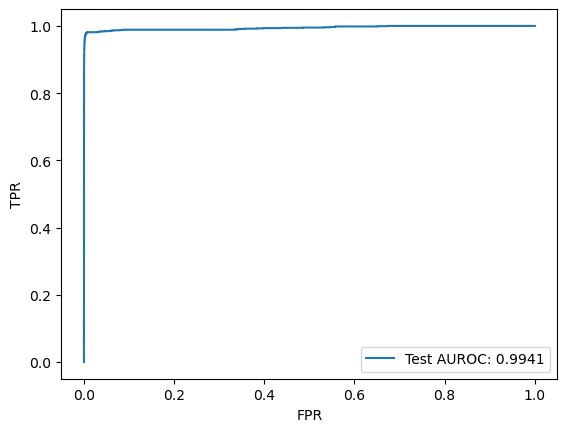

In [26]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

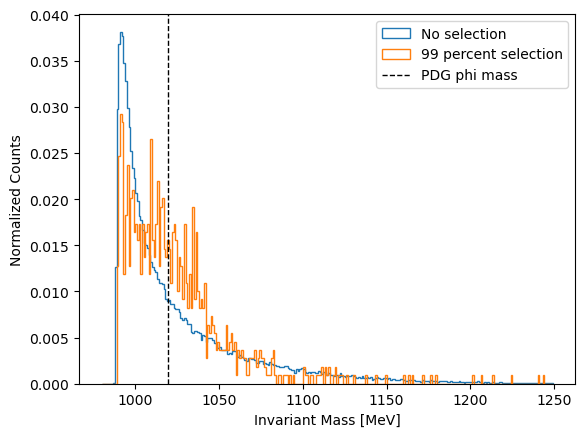

In [27]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [28]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.9046099258078935
3.4222873900293256


In [29]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/classifier_adv_2019_pass2_run"+str(run)+"_scaled.pt")
torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/adversary_adv_2019_pass2_run"+str(run)+"_scaled.pt")
